In [ ]:
%pip install qiskit qiskit-ibm-runtime
!pip install qiskit-aer
!pip install qiskit[visualization]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.4/149.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 353.0/353.0 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.9/434.9 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.

Alice's Bits:   [0 1 0 1 1 1 0 1]
Alice's Bases:  ['X', 'X', 'X', 'Z', 'X', 'Z', 'Z', 'X']
Bob's Bases:    ['Z', 'Z', 'X', 'X', 'X', 'Z', 'Z', 'Z']


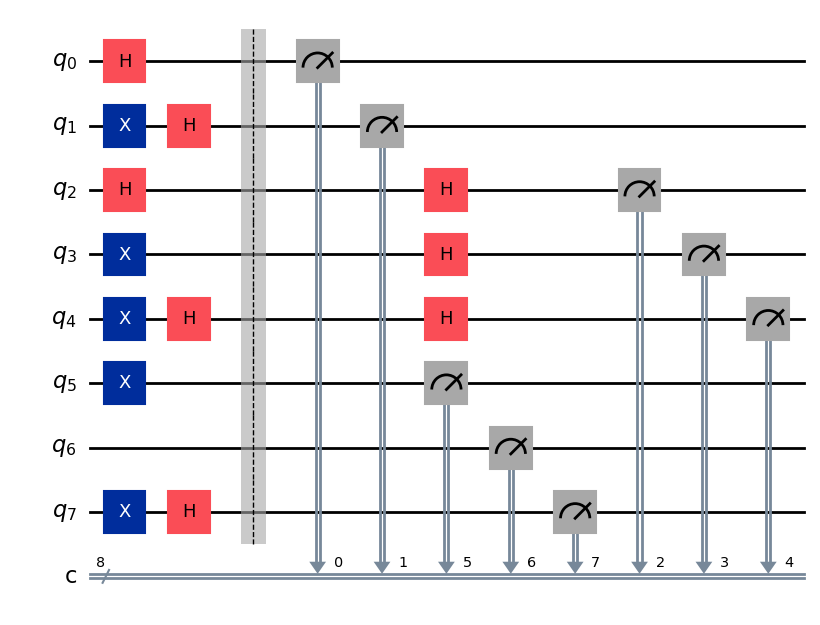

In [ ]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer
import matplotlib.pyplot as plt

# Function to generate BB84 circuit
def bb84_circuit(n):
    # Generate random bits and bases for Alice
    alice_bits = np.random.randint(2, size=n)
    alice_bases = np.random.randint(2, size=n)  # 0 for Z (computational), 1 for X (Hadamard)

    # Generate random bases for Bob (Bob does not know Alice's bits)
    bob_bases = np.random.randint(2, size=n)

    print(f"Alice's Bits:   {alice_bits}")
    print(f"Alice's Bases:  {['Z' if b == 0 else 'X' for b in alice_bases]}")
    print(f"Bob's Bases:    {['Z' if b == 0 else 'X' for b in bob_bases]}")

    # Create quantum circuit with n qubits and n classical bits
    qc = QuantumCircuit(n, n)

    # Alice's preparation
    for i in range(n):
        if alice_bits[i] == 1:
            qc.x(i)  # Apply X for bit 1
        if alice_bases[i] == 1:
            qc.h(i)  # Apply Hadamard for X basis

    qc.barrier()

    # Bob's measurement
    for i in range(n):
        if bob_bases[i] == 1:
            qc.h(i)  # Apply Hadamard before measuring in X basis
        qc.measure(i, i)

    return qc

# Number of qubits/bits
n = 8

# Generate and draw the BB84 circuit
qc = bb84_circuit(n)
qc.draw("mpl")  # "mpl" uses matplotlib for nicer diagrams



--- BB84 Simulation Summary ---
Alice Bits:      [0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1]
Alice Bases:     ['z', 'x', 'z', 'x', 'x', 'z', 'z', 'x', 'z', 'z', 'x', 'z', 'z', 'z', 'z', 'z', 'x', 'x', 'z', 'z', 'z', 'x', 'z', 'x', 'x', 'z', 'z', 'x', 'z', 'z', 'z', 'x']
Bob Bases:       ['x', 'x', 'x', 'x', 'x', 'x', 'z', 'z', 'z', 'z', 'z', 'x', 'z', 'z', 'x', 'z', 'z', 'x', 'x', 'z', 'z', 'z', 'x', 'z', 'x', 'z', 'x', 'z', 'z', 'x', 'z', 'x']
Bob Results:     [0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1]
Matched Indices: [1, 3, 4, 6, 8, 9, 12, 13, 15, 17, 19, 20, 24, 25, 28, 30, 31]
Raw Key:         [1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1]
Matched Bits:    17
Unmatched Bits:  15
Error Rate: 88.24%


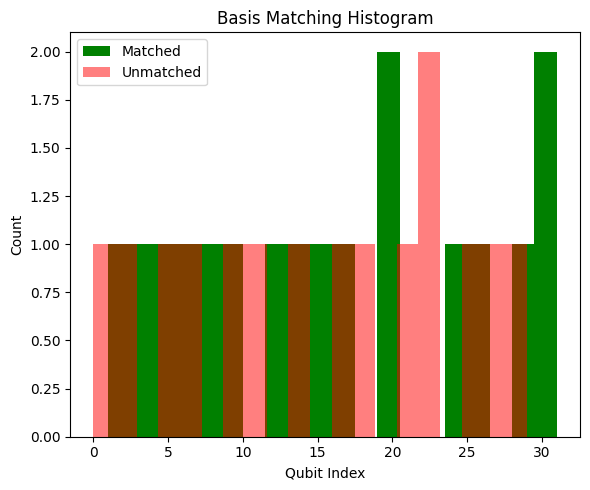

In [ ]:
import random
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit

# Number of qubits to be changed according to the user
n = 32

# Step 1: Generate Alice's random bits and bases
alice_bits = [random.randint(0, 1) for _ in range(n)]
alice_bases = [random.choice(['z', 'x']) for _ in range(n)]

# Step 2: Generate Bob's random bases
bob_bases = [random.choice(['z', 'x']) for _ in range(n)]

# Step 3: Build the BB84 circuit for all qubits
qc = QuantumCircuit(n, n)

for i in range(n):
    # Alice encodes her bit
    if alice_bits[i] == 1:
        qc.x(i)
    if alice_bases[i] == 'x':
        qc.h(i)

    # Bob measures in his basis
    if bob_bases[i] == 'x':
        qc.h(i)
    qc.measure(i, i)


# Step 4: Simulate Bob's measurement results
def measure_qubit(alice_bit, alice_basis, bob_basis):
    if alice_basis == bob_basis:
        return alice_bit
    else:
        return random.choice([0, 1])

bob_results = [measure_qubit(alice_bits[i], alice_bases[i], bob_bases[i]) for i in range(n)]

# Step 5: Sifting
matched_indices = [i for i in range(n) if alice_bases[i] == bob_bases[i]]
unmatched_indices = [i for i in range(n) if i not in matched_indices]
matched_bits = len(matched_indices)
unmatched_bits = len(unmatched_indices)
raw_key = [bob_results[i] for i in matched_indices]

# Step 6: Error Rate Calculation
error_rate = (unmatched_bits / matched_bits) * 100 if matched_bits > 0 else 0

# Step 7: Print Summary
print("\n--- BB84 Simulation Summary ---")
print("Alice Bits:     ", alice_bits)
print("Alice Bases:    ", alice_bases)
print("Bob Bases:      ", bob_bases)
print("Bob Results:    ", bob_results)
print("Matched Indices:", matched_indices)
print("Raw Key:        ", raw_key)
print("Matched Bits:   ", matched_bits)
print("Unmatched Bits: ", unmatched_bits)
print(f"Error Rate: {error_rate:.2f}%")

# Step 8: Plotting Basis Matching Histogram
plt.figure(figsize=(6, 5))
plt.hist(matched_indices, bins=20, color='green', label='Matched')
plt.hist(unmatched_indices, bins=20, color='red', alpha=0.5, label='Unmatched')
plt.title("Basis Matching Histogram")
plt.xlabel("Qubit Index")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()
